In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [6]:
def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

GOWN = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)

ws = ['0931', '0301', '0303', '0386', '0305', '0764', '0760', '0759', '0364']

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

In [10]:
df_m = GOWN.resample('MS').mean()

In [11]:
rows = {}
for w in ws:
    r = mk.correlated_seasonal_test(df_m[w].values, period=12)
    rows[w] = {"tau": r.Tau, "slope_m_yr": r.slope, "p": r.p, "verdict": r.trend}

smk = pd.DataFrame(rows).T
smk[["tau", "slope_m_yr", "p"]] = smk[["tau", "slope_m_yr", "p"]].astype(float)

print(smk["verdict"].value_counts())

verdict
decreasing    7
increasing    1
no trend      1
Name: count, dtype: int64


In [12]:
rivs = {}

r = mk.correlated_seasonal_test(brac.values, period=12)
rivs['BRatC'] = {"tau": r.Tau, "slope_m3_yr": r.slope, "p": r.p, "verdict": r.trend}

r = mk.correlated_seasonal_test(krns.values, period=12)
rivs['KRnS'] = {"tau": r.Tau, "slope_m3_yr": r.slope, "p": r.p, "verdict": r.trend}

rivs = pd.DataFrame(rivs).T
rivs

,tau,slope_m3_yr,p,verdict
BRatC,-0.044795,-0.003051,0.018879,decreasing
KRnS,-0.003283,-0.00037,0.928648,no trend


In [13]:
sen = smk.sort_values("slope_m_yr")
print("strongest declines:\n", sen[["slope_m_yr", "tau", "p"]].head(5))
print("\nstrongest rises:\n", sen[["slope_m_yr", "tau", "p"]].tail(5))
print(f"\n{(smk['p'] < 0.05).sum()} of {len(smk)} 'significant' at p<0.05")

strongest declines:
       slope_m_yr       tau         p
0303   -0.044508 -0.325439  0.004460
0764   -0.038566 -0.336842  0.008247
0305   -0.031324 -0.381579  0.000129
0759   -0.016055 -0.214035  0.039079
0364   -0.014041 -0.335965  0.024932

strongest rises:
       slope_m_yr       tau         p
0364   -0.014041 -0.335965  0.024932
0386   -0.013536 -0.450000  0.000070
0301   -0.012168 -0.276316  0.015159
0760   -0.001375 -0.022807  0.829248
0931    0.035785  0.276316  0.013236

8 of 9 'significant' at p<0.05


In [14]:
smk.sort_values("slope_m_yr")

,tau,slope_m_yr,p,verdict
0303,-0.325439,-0.044508,0.004460,decreasing
0764,-0.336842,-0.038566,0.008247,decreasing
0305,-0.381579,-0.031324,0.000129,decreasing
0759,-0.214035,-0.016055,0.039079,decreasing
0364,-0.335965,-0.014041,0.024932,decreasing
0386,-0.450000,-0.013536,0.000070,decreasing
0301,-0.276316,-0.012168,0.015159,decreasing
0760,-0.022807,-0.001375,0.829248,no trend
0931,0.276316,0.035785,0.013236,increasing


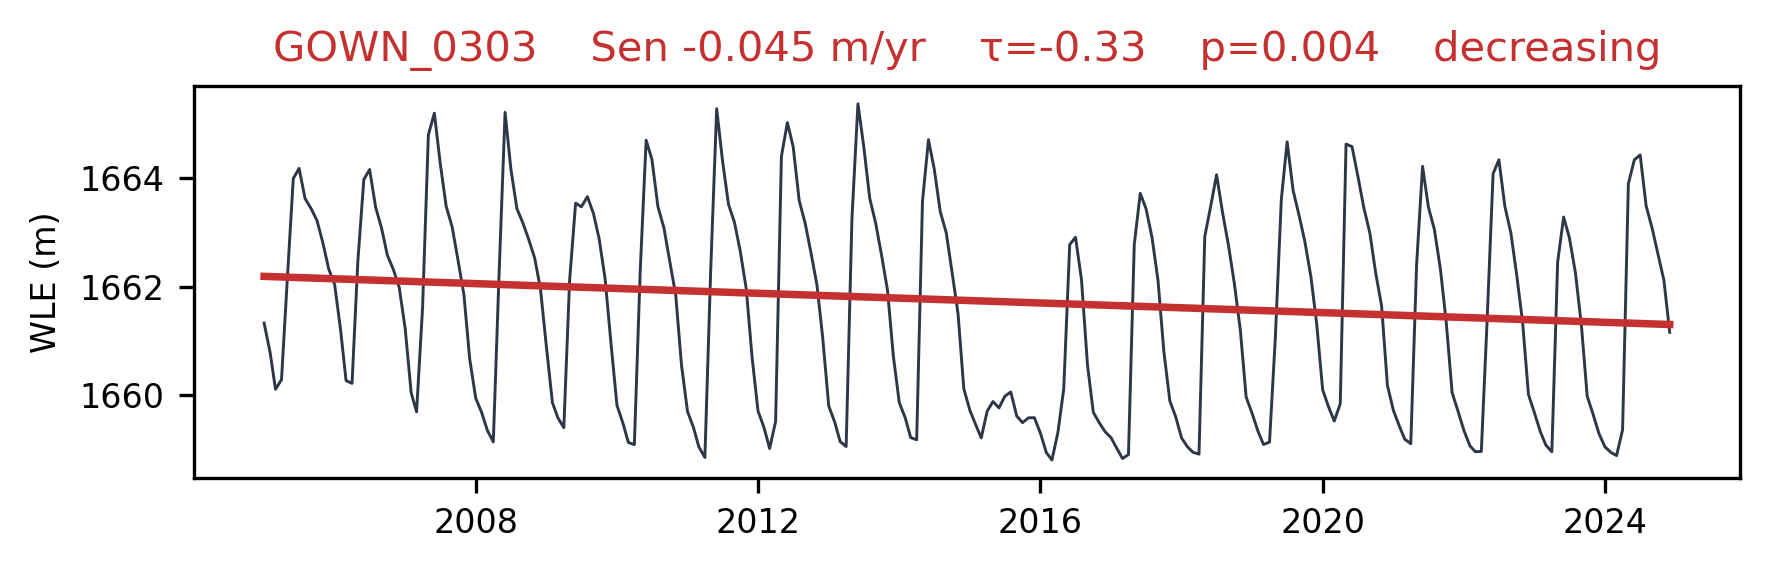

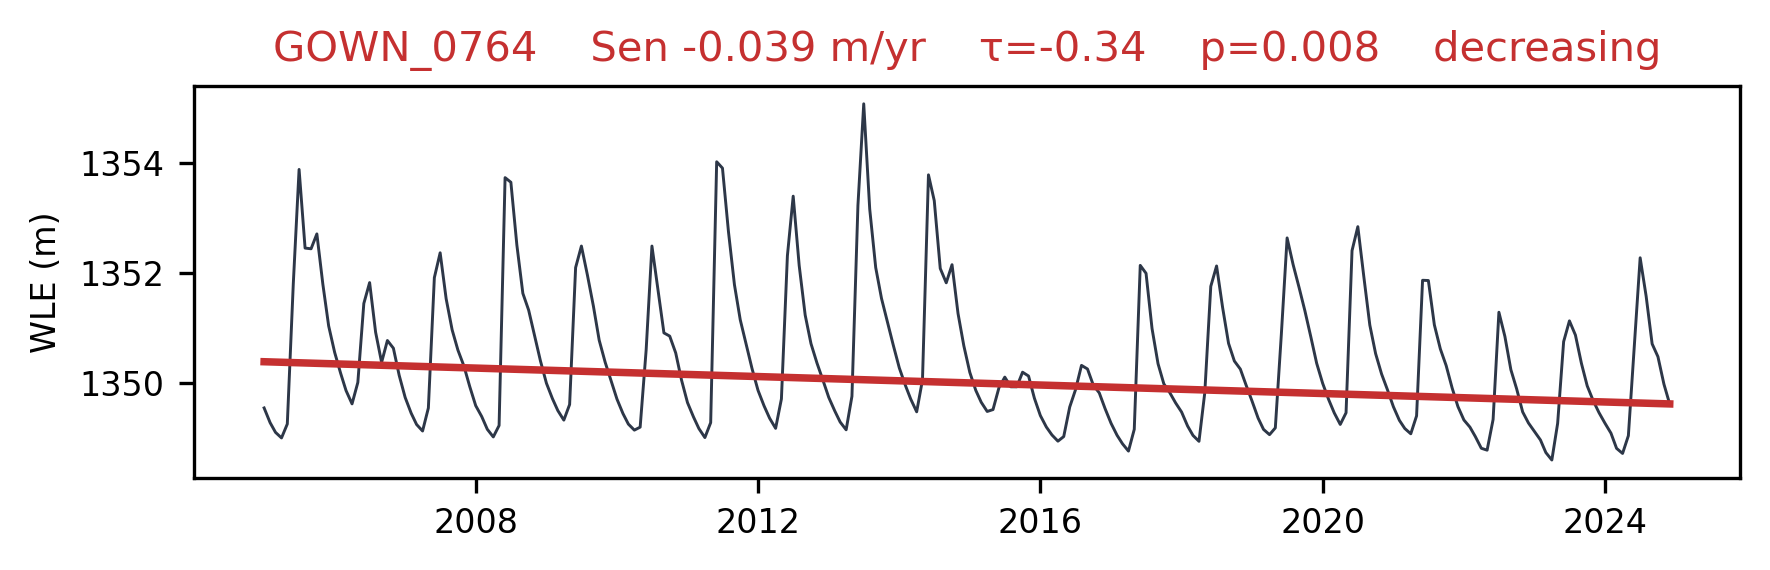

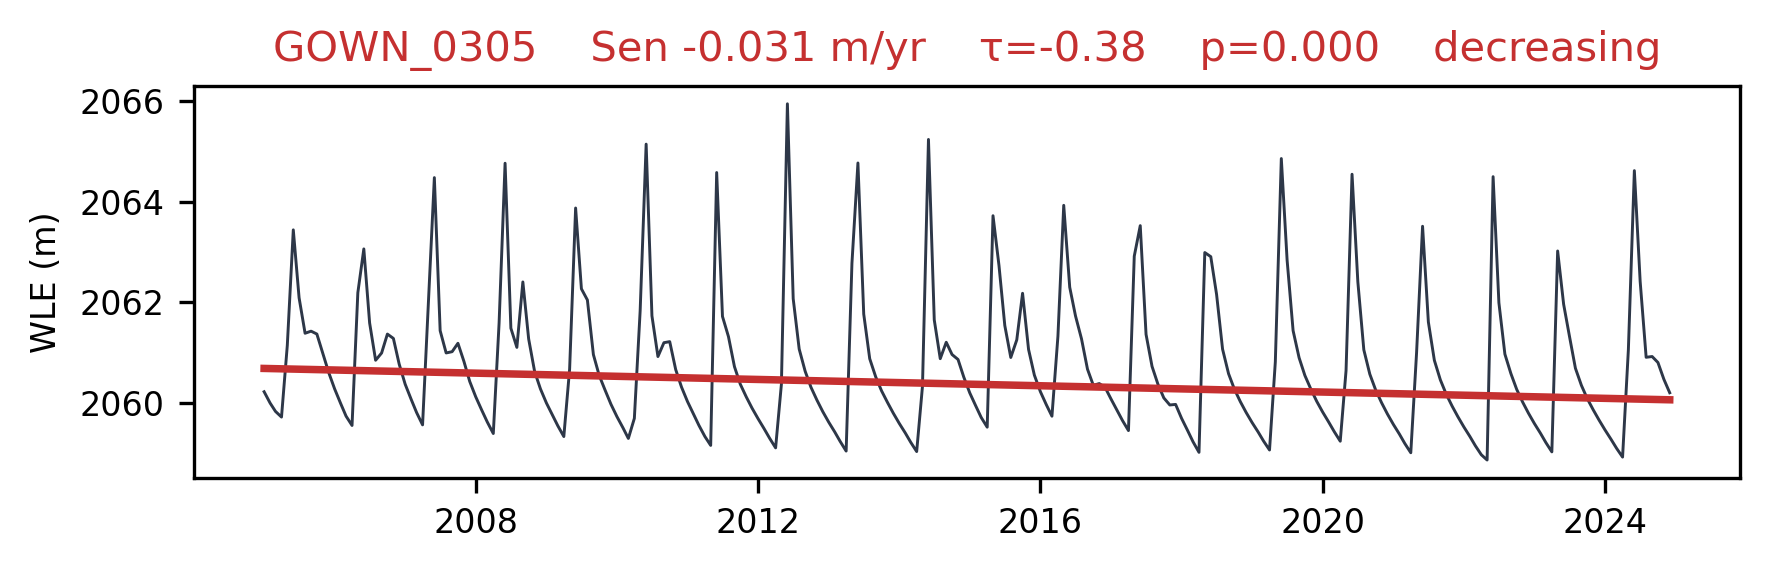

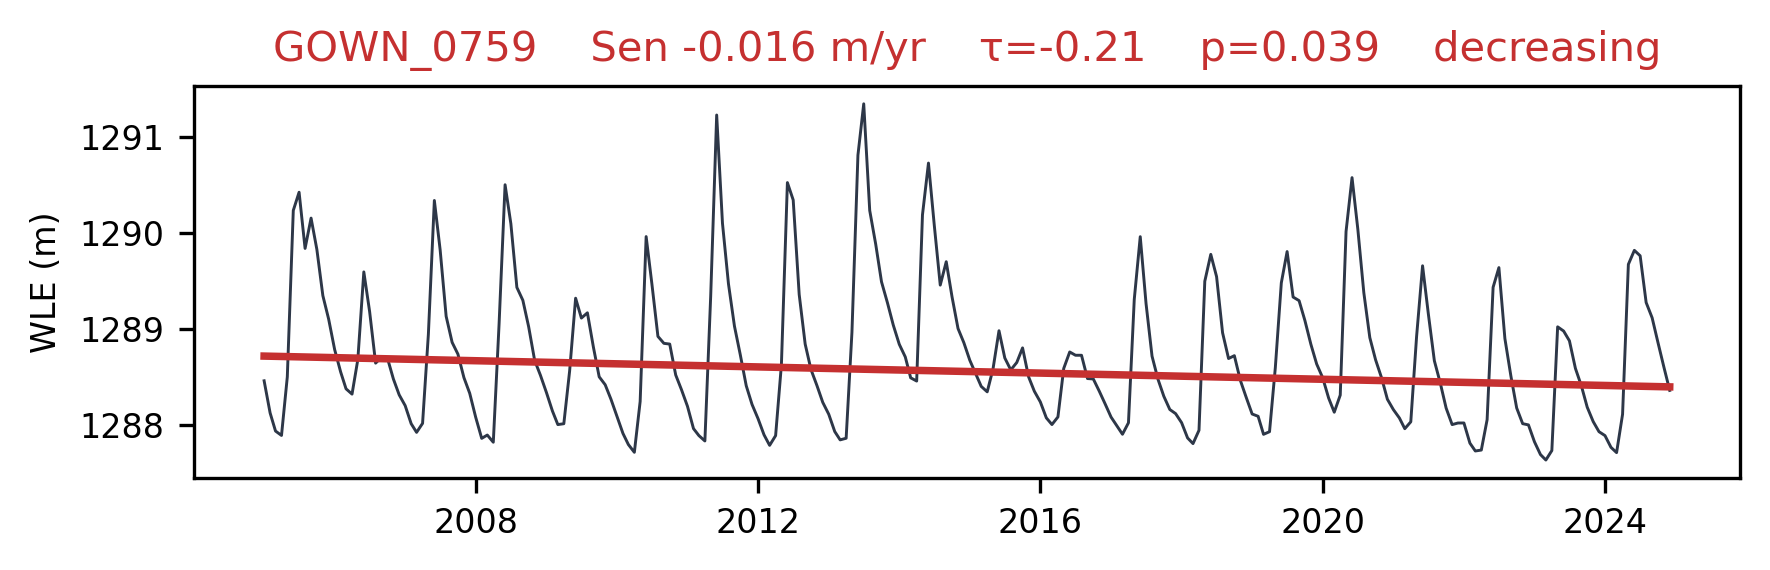

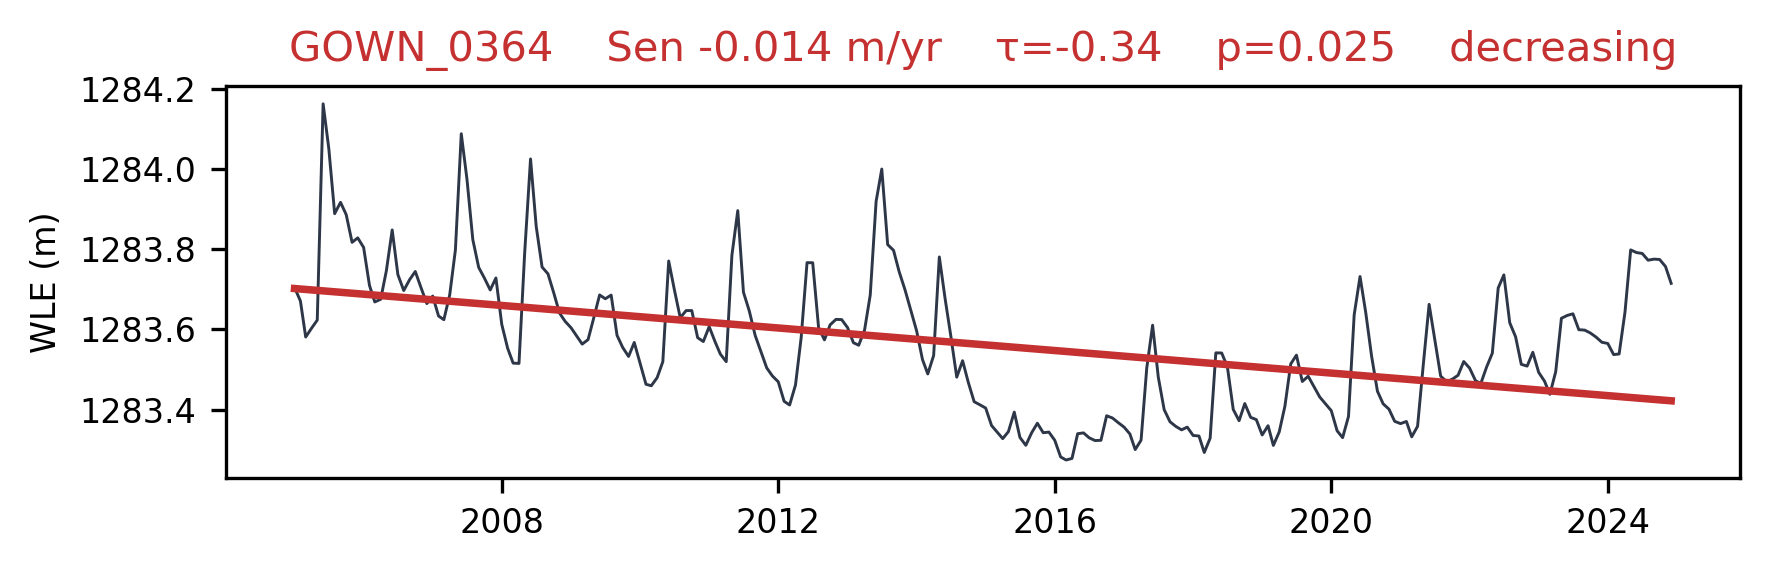

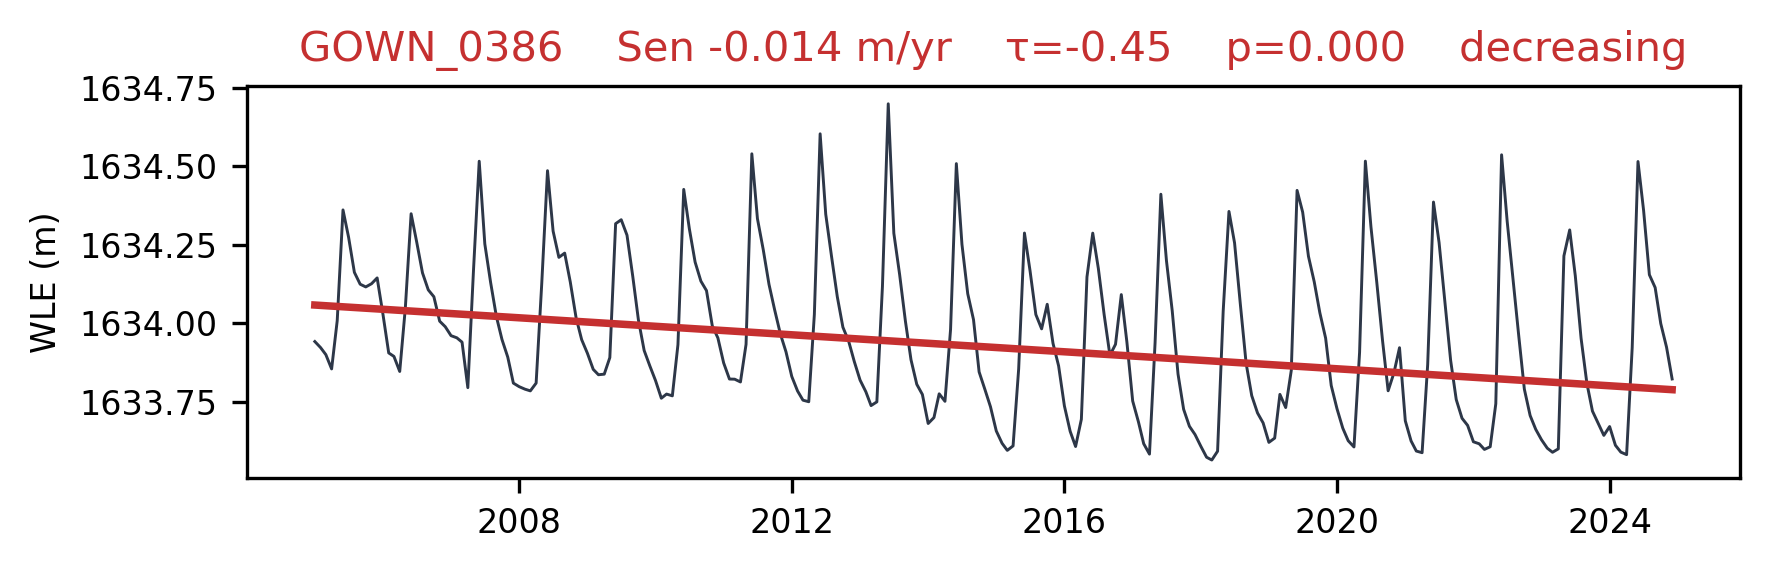

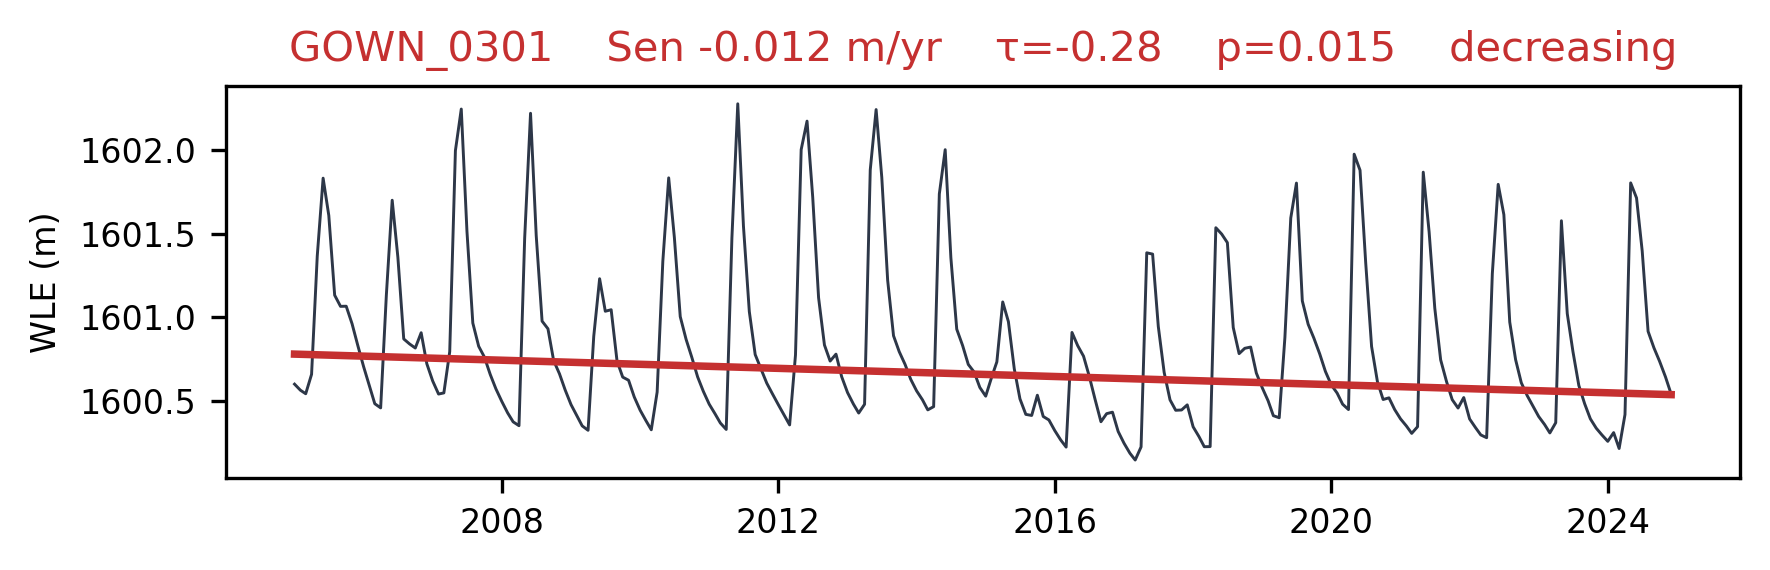

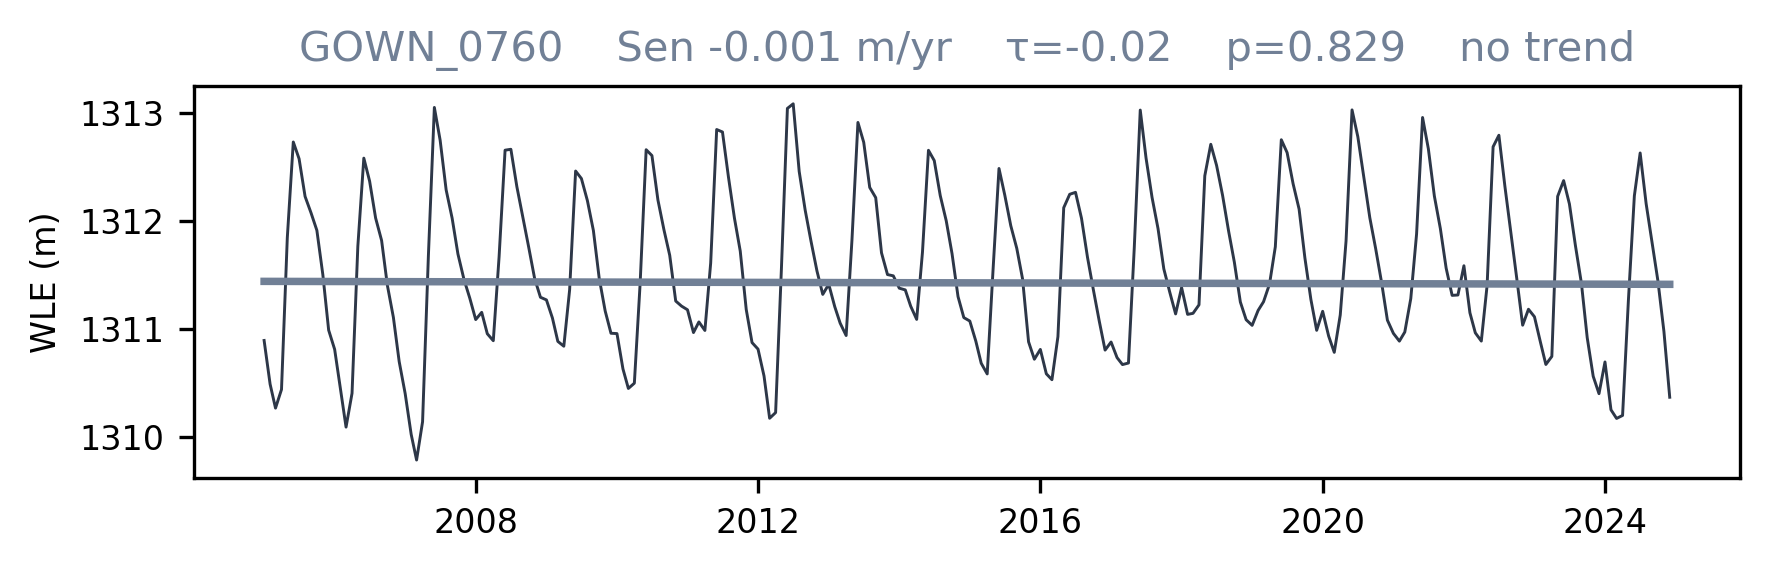

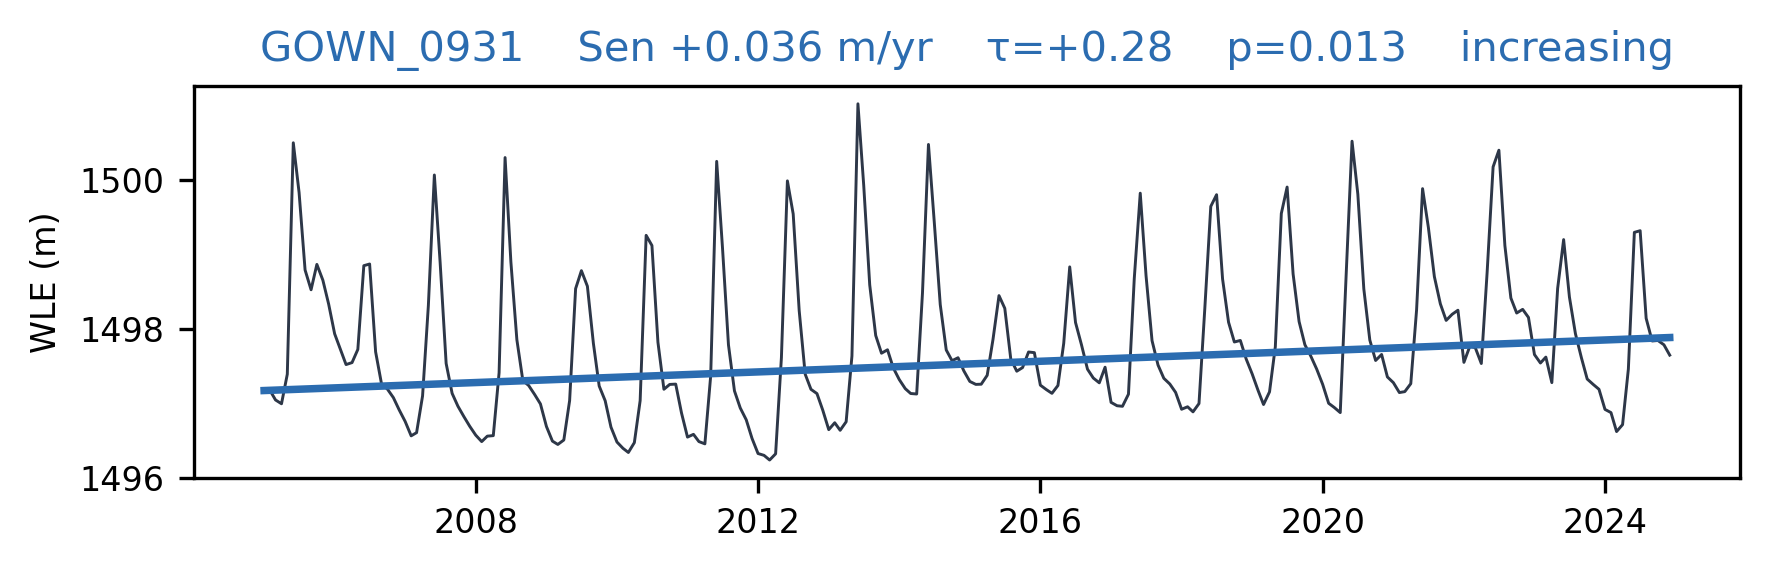

In [15]:
order = smk.sort_values("slope_m_yr").index          # declines first
tnum = np.arange(len(df_m))                          # month counter for the line
tmed = np.median(tnum)

vcolor = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#718096"}

for w in order:
    y = df_m[w]
    slope_mo = smk.loc[w, "slope_m_yr"] / 12       # back to per-month for plotting
    ymed = y.median()
    line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

    v = smk.loc[w, "verdict"]
    fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
    ax.plot(df_m.index, y, lw=0.7, color="#2d3748")
    ax.plot(df_m.index, line, lw=1.8, color=vcolor[v])

    ax.set_title(
        f"GOWN_{w}    Sen {smk.loc[w,'slope_m_yr']:+.3f} m/yr    "
        f"τ={smk.loc[w,'tau']:+.2f}    p={smk.loc[w,'p']:.3f}    {v}",
        fontsize=10, color=vcolor[v])
    ax.set_ylabel("WLE (m)", fontsize=8)
    ax.tick_params(labelsize=8)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

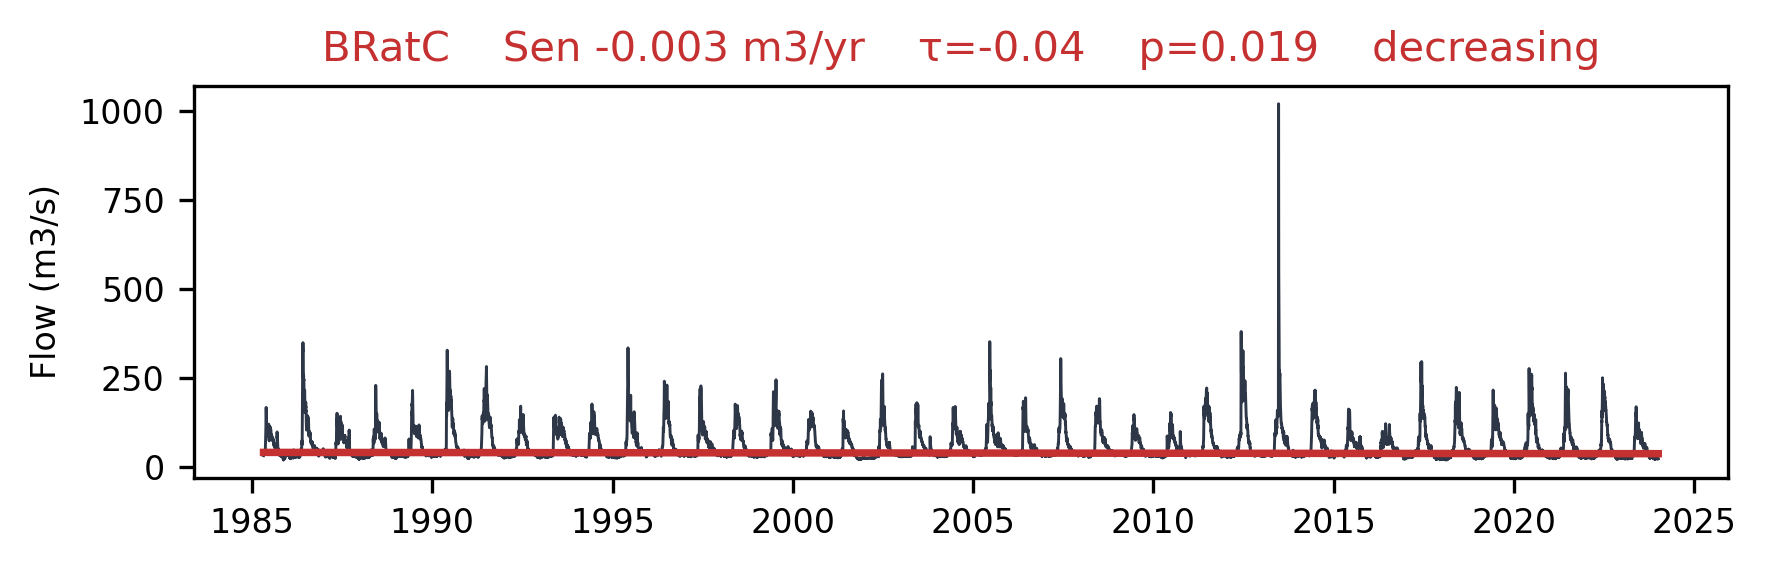

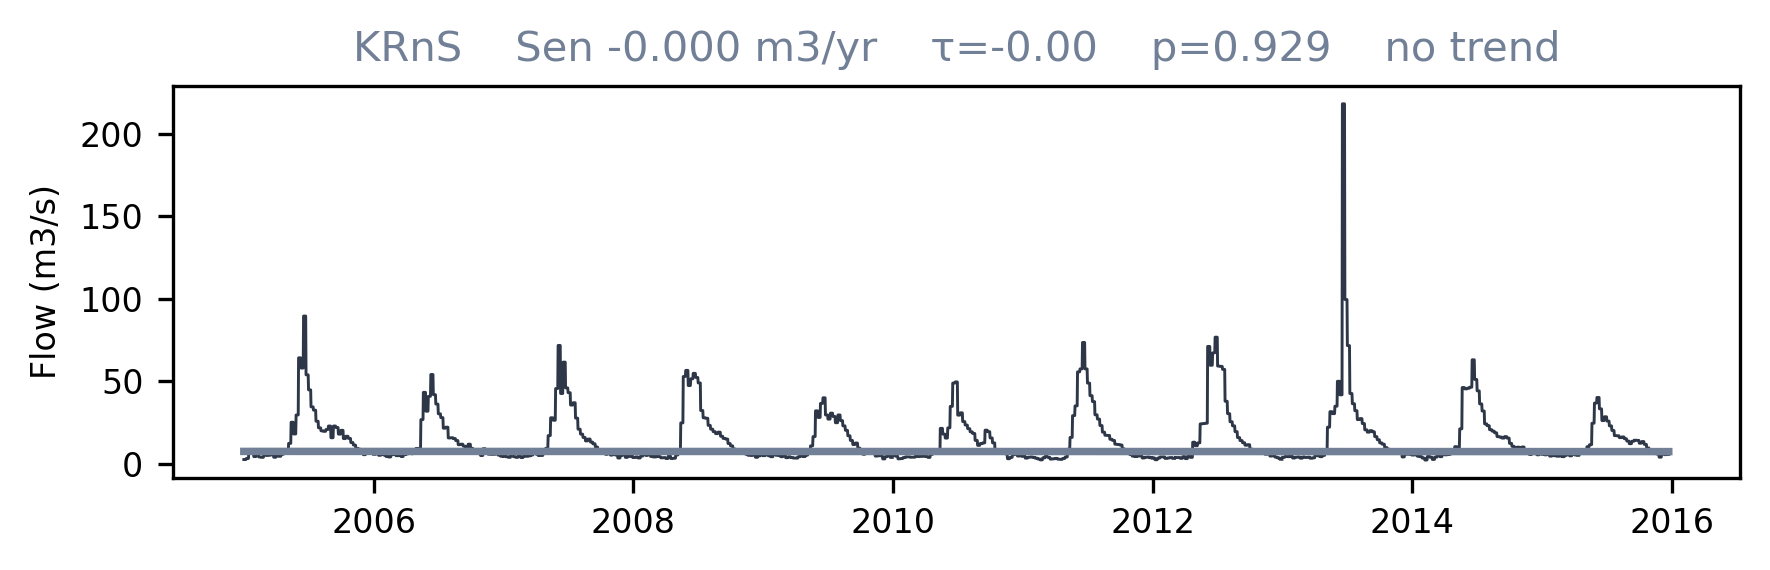

In [16]:
for riv, r in {'BRatC': brac, 'KRnS': krns}.items():
    tnum = np.arange(len(r))                          # month counter for the line
    tmed = np.median(tnum)

    y = r
    slope_mo = rivs.loc[riv, "slope_m3_yr"] / 12       # back to per-month for plotting
    ymed = y.median()
    line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

    v = rivs.loc[riv, "verdict"]
    fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
    ax.plot(y.index, y, lw=0.7, color="#2d3748")
    ax.plot(y.index, line, lw=1.8, color=vcolor[v])

    ax.set_title(
        f"{riv}    Sen {rivs.loc[riv, 'slope_m3_yr']:+.3f} m3/yr    "
        f"τ={rivs.loc[riv,'tau']:+.2f}    p={rivs.loc[riv,'p']:.3f}    {v}",
        fontsize=10, color=vcolor[v])
    ax.set_ylabel("Flow (m3/s)", fontsize=8)
    ax.tick_params(labelsize=8)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

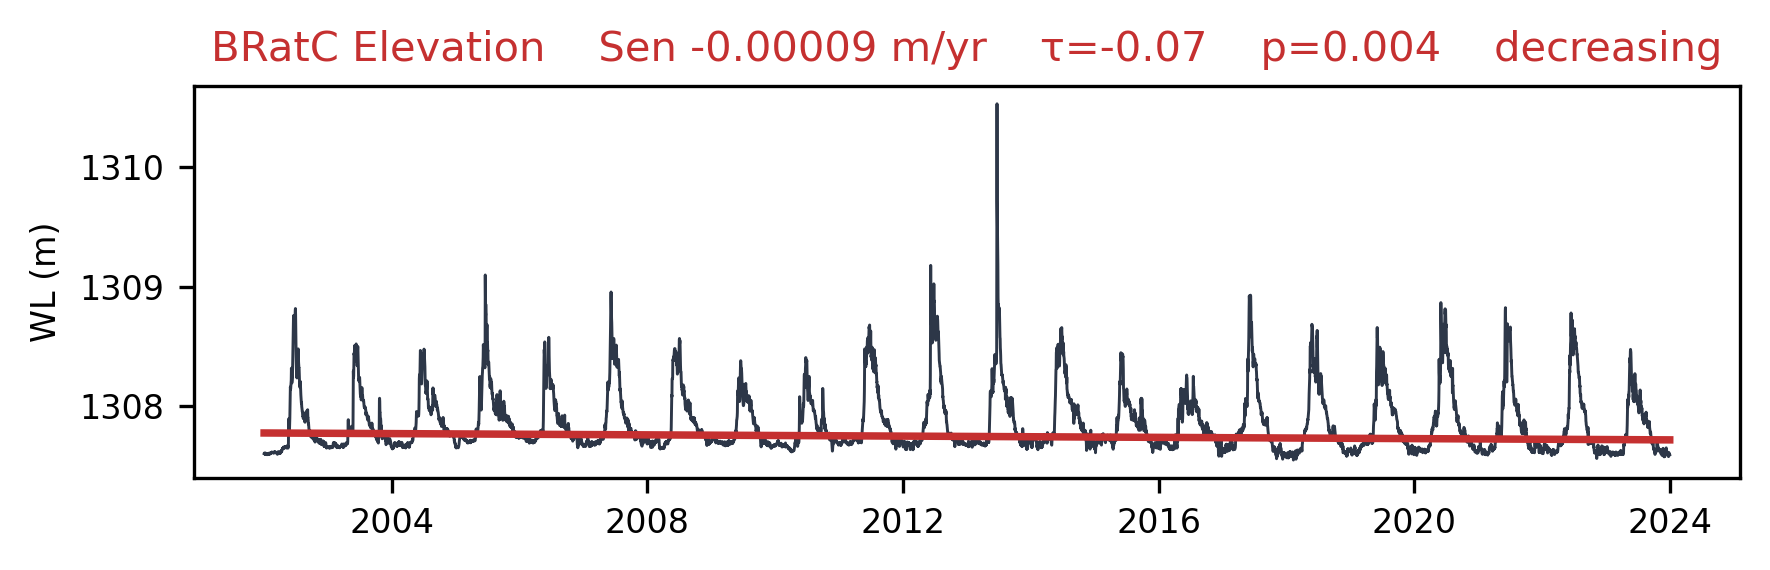

In [17]:
r = mk.correlated_seasonal_test(brac_e.values, period=12)

tnum = np.arange(len(brac_e))                          # month counter for the line
tmed = np.median(tnum)

slope_mo = r.slope / 12       # back to per-month for plotting
ymed = brac_e.median()
line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

v = r.trend
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(brac_e.index, brac_e, lw=0.7, color="#2d3748")
ax.plot(brac_e.index, line, lw=1.8, color=vcolor[v])

ax.set_title(
    f"BRatC Elevation    Sen {r.slope:+.5f} m/yr    "
    f"τ={r.Tau:+.2f}    p={r.p:.3f}    {v}",
    fontsize=10, color=vcolor[v])
ax.set_ylabel("WL (m)", fontsize=8)
ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)

In [20]:
lkl = lkl.loc['2005':]

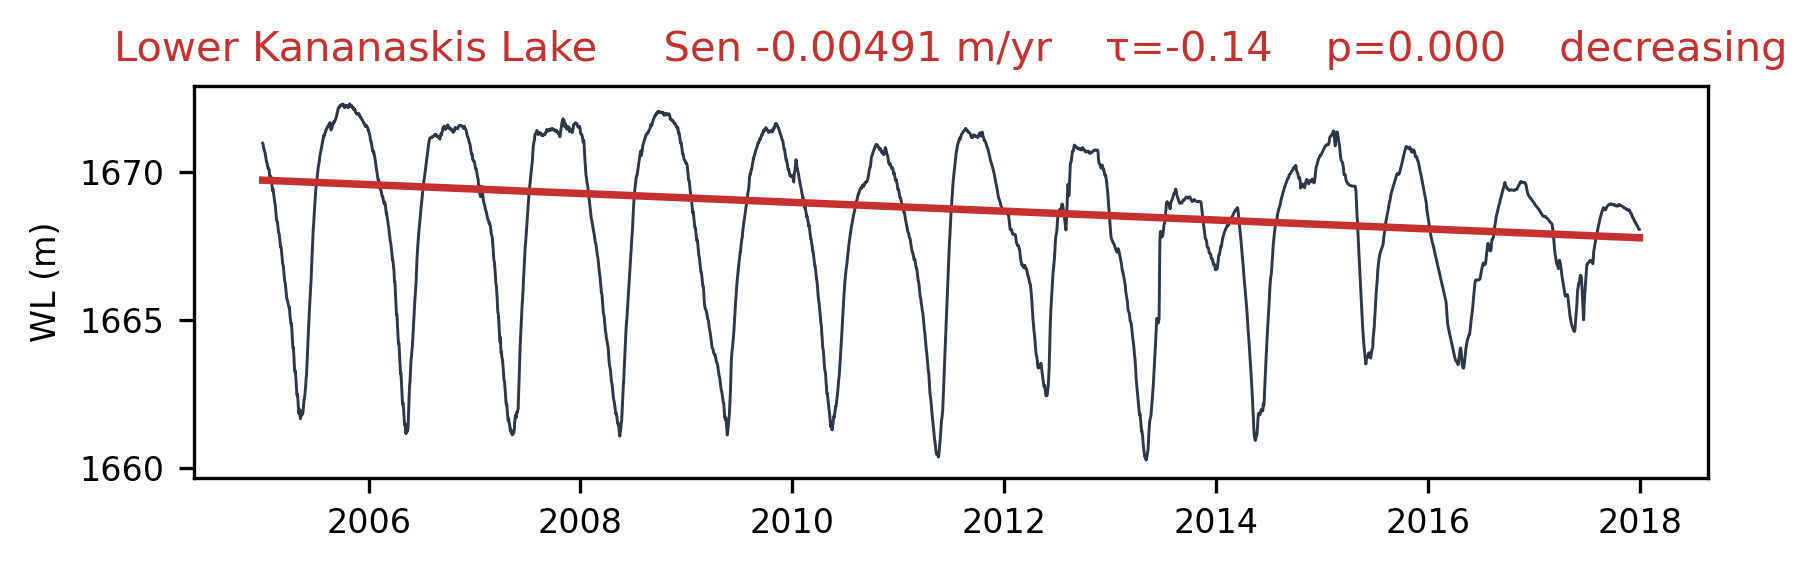

In [21]:
r = mk.correlated_seasonal_test(lkl.values, period=12)

tnum = np.arange(len(lkl))                          # month counter for the line
tmed = np.median(tnum)

slope_mo = r.slope / 12       # back to per-month for plotting
ymed = lkl.median()
line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

v = r.trend
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(lkl.index, lkl, lw=0.7, color="#2d3748")
ax.plot(lkl.index, line, lw=1.8, color=vcolor[v])

ax.set_title(
    f"Lower Kananaskis Lake     Sen {r.slope:+.5f} m/yr    "
    f"τ={r.Tau:+.2f}    p={r.p:.3f}    {v}",
    fontsize=10, color=vcolor[v])
ax.set_ylabel("WL (m)", fontsize=8)
ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)

In [27]:
lkl.mean()

np.float64(1668.0250183235046)

In [23]:
bl = bl.resample('MS').mean()

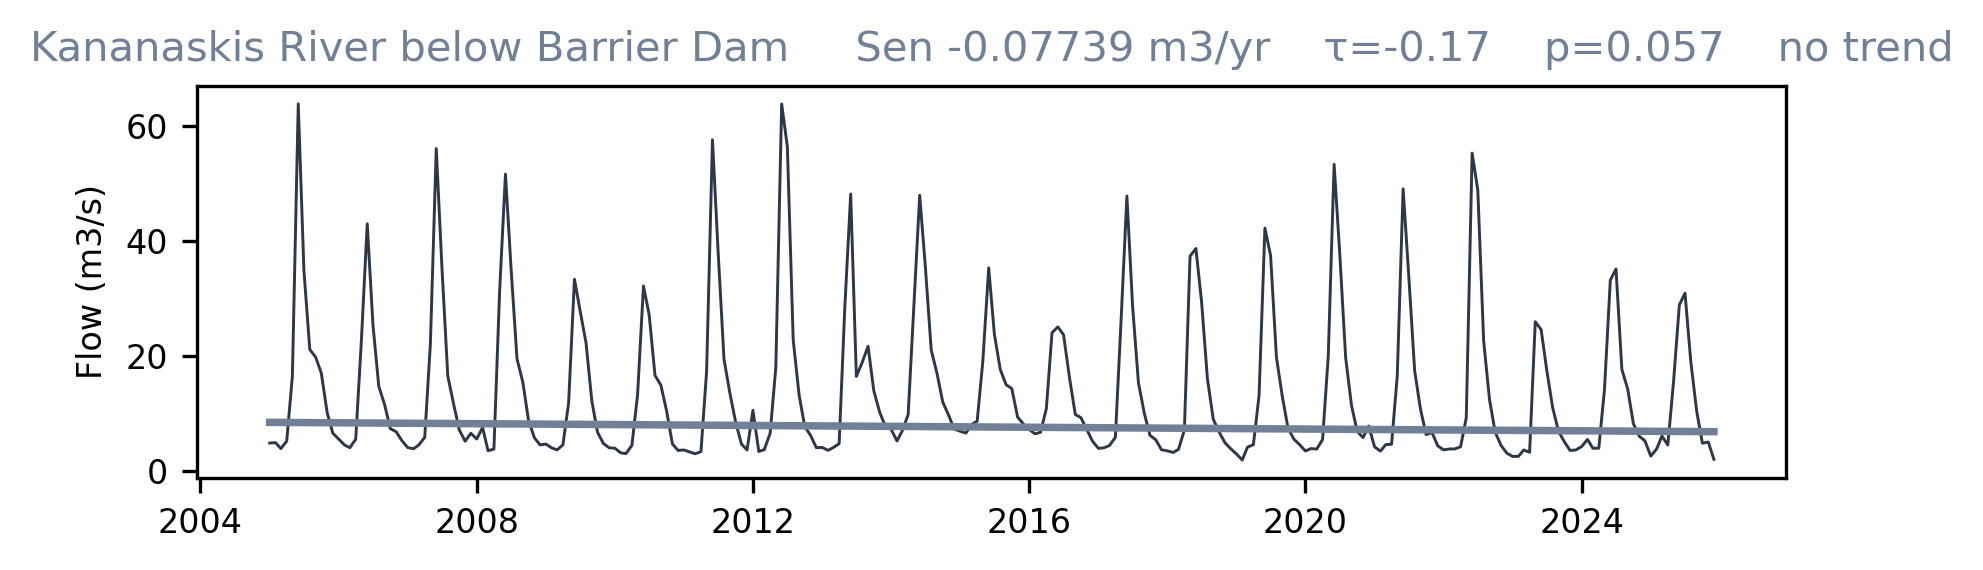

In [24]:
bl = bl.loc['2005':]
r = mk.correlated_seasonal_test(bl.values, period=12)

tnum = np.arange(len(bl))                          # month counter for the line
tmed = np.median(tnum)

slope_mo = r.slope / 12       # back to per-month for plotting
ymed = bl.median()
line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

v = r.trend
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(bl.index, bl, lw=0.7, color="#2d3748")
ax.plot(bl.index, line, lw=1.8, color=vcolor[v])

ax.set_title(
    f"Kananaskis River below Barrier Dam     Sen {r.slope:+.5f} m3/yr    "
    f"τ={r.Tau:+.2f}    p={r.p:.3f}    {v}",
    fontsize=10, color=vcolor[v])
ax.set_ylabel("Flow (m3/s)", fontsize=8)
ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)

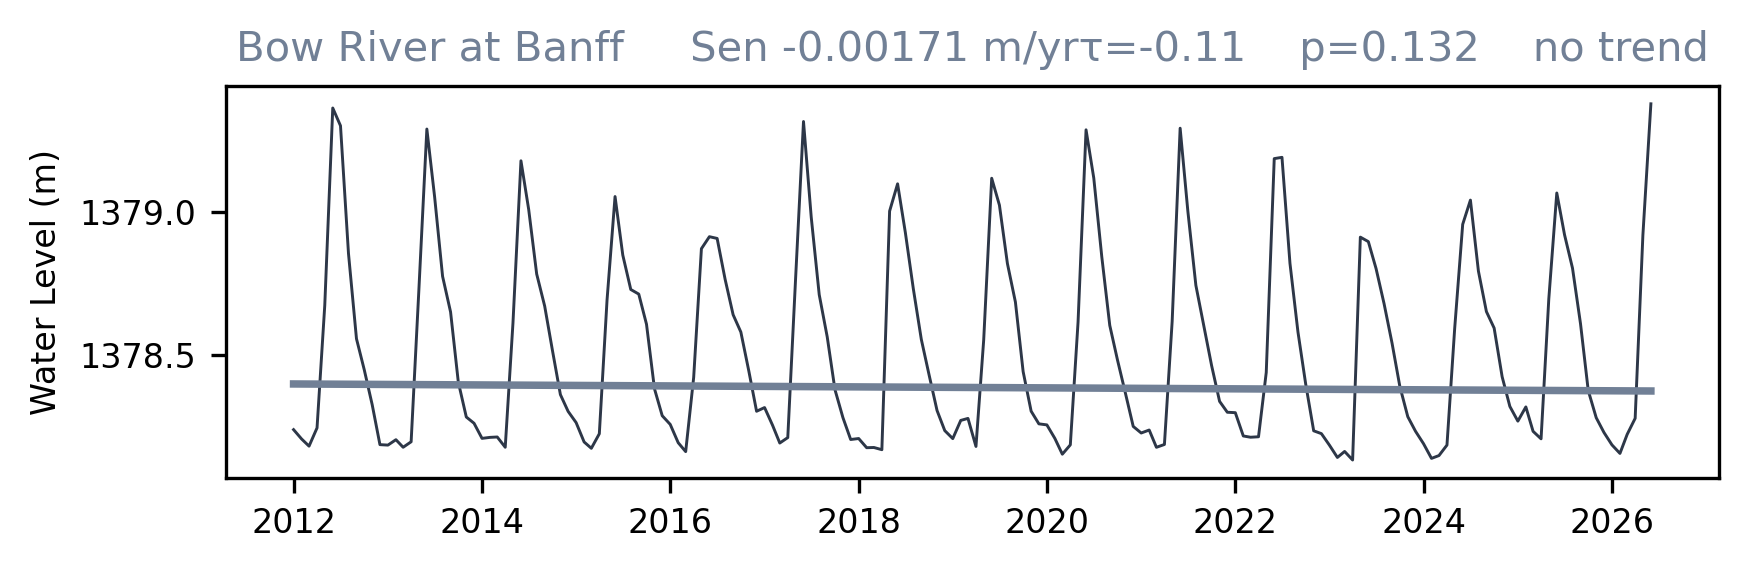

In [25]:
brab = brab.resample('MS').mean()

brab = brab.loc['2005':]
r = mk.correlated_seasonal_test(brab.values, period=12)

tnum = np.arange(len(brab))                          # month counter for the line
tmed = np.median(tnum)

slope_mo = r.slope / 12       # back to per-month for plotting
ymed = brab.median()
line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

v = r.trend
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(brab.index, brab, lw=0.7, color="#2d3748")
ax.plot(brab.index, line, lw=1.8, color=vcolor[v])

ax.set_title(
    f"Bow River at Banff     Sen {r.slope:+.5f} m/yr"
    f"τ={r.Tau:+.2f}    p={r.p:.3f}    {v}",
    fontsize=10, color=vcolor[v])
ax.set_ylabel("Water Level (m)", fontsize=8)
ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)